### Imports

In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import pandas as pd

from dataclasses import dataclass

### Environment Setup

In [2]:
ENV_NAME = "MountainCar-v0"
env = gym.make(ENV_NAME)

print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Observation low:", env.observation_space.low)
print("Observation high:", env.observation_space.high)
print("Number of actions:", env.action_space.n)

env.close()

Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Action space: Discrete(3)
Observation low: [-1.2  -0.07]
Observation high: [0.6  0.07]
Number of actions: 3


### Global Constants

In [3]:
OBS_LOW = np.array([-1.2, -0.07], dtype=np.float64)
OBS_HIGH = np.array([0.6, 0.07], dtype=np.float64)

POSITION_LOW, VELOCITY_LOW = OBS_LOW
POSITION_HIGH, VELOCITY_HIGH = OBS_HIGH

N_ACTIONS = 3

# MountainCar-v0 actions:
# 0 = push left
# 1 = no push
# 2 = push right

ACTION_NAMES = {
    0: "Left",
    1: "Neutral",
    2: "Right"
}

### Tile Coding Feature Constructor

In [4]:
class TileCoder:
    def __init__(
        self,
        low,
        high,
        num_tilings=8,
        tiles_per_dim=(8, 8),
        offsets=None
    ):
        self.low = np.asarray(low, dtype=np.float64)
        self.high = np.asarray(high, dtype=np.float64)

        self.num_tilings = int(num_tilings)
        self.tiles_per_dim = np.asarray(tiles_per_dim, dtype=np.int64)

        self.num_dims = len(self.low)

        self.tiles_per_tiling = int(np.prod(self.tiles_per_dim))
        self.total_features = self.num_tilings * self.tiles_per_tiling

        self.state_range = self.high - self.low

        # Tile width for each dimension.
        # We use tiles_per_dim - 1 so that offset tilings cover boundaries better.
        self.tile_width = self.state_range / (self.tiles_per_dim - 1)

        if offsets is None:
            self.offsets = self._create_default_offsets()
        else:
            self.offsets = np.asarray(offsets, dtype=np.float64)

        if self.offsets.shape != (self.num_tilings, self.num_dims):
            raise ValueError(
                f"offsets must have shape ({self.num_tilings}, {self.num_dims})"
            )
    def _create_default_offsets(self):
        
        offsets = np.zeros((self.num_tilings, self.num_dims), dtype=np.float64)

        for tiling in range(self.num_tilings):
            fraction = tiling / self.num_tilings

            for dim in range(self.num_dims):
                offsets[tiling, dim] = fraction * self.tile_width[dim]

        return offsets
    
    def get_active_tiles(self, state):

        state = np.asarray(state, dtype=np.float64)
        state = np.clip(state, self.low, self.high)

        active_indices = []

        for tiling in range(self.num_tilings):
            shifted_state = state - self.low + self.offsets[tiling]

            tile_coords = np.floor(shifted_state / self.tile_width).astype(int)
            tile_coords = np.clip(tile_coords, 0, self.tiles_per_dim - 1)

            local_tile_index = np.ravel_multi_index(
                tile_coords,
                self.tiles_per_dim
            )

            global_tile_index = tiling * self.tiles_per_tiling + local_tile_index

            active_indices.append(global_tile_index)

        return np.array(active_indices, dtype=np.int64)
    
    def get_feature_vector(self, state):

        features = np.zeros(self.total_features, dtype=np.float64)
        active_tiles = self.get_active_tiles(state)
        features[active_tiles] = 1.0
        return features
    
    def describe(self):
        return {
            "num_tilings": self.num_tilings,
            "tiles_per_dim": tuple(self.tiles_per_dim),
            "tiles_per_tiling": self.tiles_per_tiling,
            "total_features": self.total_features,
            "active_features_per_state": self.num_tilings,
            "tile_width": self.tile_width,
        }

### Testing Tile Coder

In [5]:
tile_coder = TileCoder(
    low=OBS_LOW,
    high=OBS_HIGH,
    num_tilings=8,
    tiles_per_dim=(8, 8)
)

print(tile_coder.describe())

test_state = np.array([-0.5, 0.02])
active_tiles = tile_coder.get_active_tiles(test_state)
feature_vector = tile_coder.get_feature_vector(test_state)

print("Test state:", test_state)
print("Active tile indices:", active_tiles)
print("Number of active features:", np.sum(feature_vector))
print("Feature vector length:", len(feature_vector))

{'num_tilings': 8, 'tiles_per_dim': (np.int64(8), np.int64(8)), 'tiles_per_tiling': 64, 'total_features': 512, 'active_features_per_state': 8, 'tile_width': array([0.25714286, 0.02      ])}
Test state: [-0.5   0.02]
Active tile indices: [ 20  84 148 220 285 349 413 477]
Number of active features: 8.0
Feature vector length: 512


### Epsilon Schedules

In [6]:
def constant_epsilon(epsilon_value):
    def schedule(episode):
        return epsilon_value
    return schedule


def linear_decay_epsilon(start=1.0, end=0.05, decay_episodes=500):
    def schedule(episode):
        fraction = min(episode / decay_episodes, 1.0)
        return start + fraction * (end - start)
    return schedule


def exponential_decay_epsilon(start=1.0, end=0.05, decay_rate=0.995):
    def schedule(episode):
        return max(end, start * (decay_rate ** episode))
    return schedule

### Semi Gradient SARSA Agent

In [7]:
class SemiGradientSARSAAgent:

    def __init__(
        self,
        tile_coder,
        num_actions=3,
        alpha=0.1,
        gamma=1.0,
        epsilon_schedule=constant_epsilon(0.1),
        seed=42
    ):
        self.tile_coder = tile_coder
        self.num_actions = num_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon_schedule = epsilon_schedule

        self.rng = np.random.default_rng(seed)

        self.weights = np.zeros(
            (num_actions, tile_coder.total_features),
            dtype=np.float64
        )

    def q_value(self, state, action):
        active_tiles = self.tile_coder.get_active_tiles(state)
        return np.sum(self.weights[action, active_tiles])

    def q_values(self, state):
        active_tiles = self.tile_coder.get_active_tiles(state)
        return np.sum(self.weights[:, active_tiles], axis=1)

    def select_action(self, state, epsilon):
        if self.rng.random() < epsilon:
            return int(self.rng.choice(self.num_actions))

        q_vals = self.q_values(state)
        return int(np.argmax(q_vals))

    def update(self, state, action, target):
        active_tiles = self.tile_coder.get_active_tiles(state)

        prediction = np.sum(self.weights[action, active_tiles])
        td_error = target - prediction

        self.weights[action, active_tiles] += self.alpha * td_error

        return td_error

### Training Configuration

In [8]:
@dataclass
class MountainCarConfig:
    num_episodes: int = 1000
    max_steps_per_episode: int = 200
    alpha: float = 0.1
    gamma: float = 1.0
    num_tilings: int = 8
    tiles_per_dim: tuple = (8, 8)
    epsilon_schedule: callable = constant_epsilon(0.1)
    seed: int = 42

### Training Semi Gradient SARSA Agent

In [9]:
def train_semi_gradient_sarsa(config):
    env = gym.make(ENV_NAME)

    tile_coder = TileCoder(
        low=OBS_LOW,
        high=OBS_HIGH,
        num_tilings=config.num_tilings,
        tiles_per_dim=config.tiles_per_dim
    )

    # Common convention:
    # divide alpha by number of tilings because each update touches num_tilings weights.
    effective_alpha = config.alpha / config.num_tilings

    agent = SemiGradientSARSAAgent(
        tile_coder=tile_coder,
        num_actions=N_ACTIONS,
        alpha=effective_alpha,
        gamma=config.gamma,
        epsilon_schedule=config.epsilon_schedule,
        seed=config.seed
    )

    episode_returns = np.zeros(config.num_episodes, dtype=np.float64)
    episode_lengths = np.zeros(config.num_episodes, dtype=np.int64)
    td_errors_per_episode = np.zeros(config.num_episodes, dtype=np.float64)
    reached_goal = np.zeros(config.num_episodes, dtype=bool)

    for episode in range(config.num_episodes):
        epsilon = config.epsilon_schedule(episode)

        state, info = env.reset(seed=config.seed + episode)
        action = agent.select_action(state, epsilon)

        total_reward = 0.0
        td_errors = []

        for step in range(config.max_steps_per_episode):
            next_state, reward, terminated, truncated, info = env.step(action)

            total_reward += reward

            if terminated:
                target = reward
                td_error = agent.update(state, action, target)
                td_errors.append(abs(td_error))
                reached_goal[episode] = True
                break

            next_action = agent.select_action(next_state, epsilon)

            next_q = agent.q_value(next_state, next_action)
            target = reward + config.gamma * next_q

            td_error = agent.update(state, action, target)
            td_errors.append(abs(td_error))

            state = next_state
            action = next_action

            if truncated:
                break

        episode_returns[episode] = total_reward
        episode_lengths[episode] = step + 1

        if len(td_errors) > 0:
            td_errors_per_episode[episode] = np.mean(td_errors)

    env.close()

    return {
        "agent": agent,
        "tile_coder": tile_coder,
        "weights": agent.weights,
        "episode_returns": episode_returns,
        "episode_lengths": episode_lengths,
        "td_errors": td_errors_per_episode,
        "reached_goal": reached_goal,
        "config": config
    }

In [10]:
main_config = MountainCarConfig(
    num_episodes=1000,
    max_steps_per_episode=200,
    alpha=0.4,
    gamma=1.0,
    num_tilings=8,
    tiles_per_dim=(8, 8),
    epsilon_schedule=linear_decay_epsilon(
        start=1.0,
        end=0.05,
        decay_episodes=800
    ),
    seed=42
)

main_result = train_semi_gradient_sarsa(main_config)

print("Final average episode length over last 100 episodes:",
      np.mean(main_result["episode_lengths"][-100:]))

print("Final average return over last 100 episodes:",
      np.mean(main_result["episode_returns"][-100:]))

print("Goal reached rate over last 100 episodes:",
      np.mean(main_result["reached_goal"][-100:]))

Final average episode length over last 100 episodes: 121.78
Final average return over last 100 episodes: -121.78
Goal reached rate over last 100 episodes: 1.0


### Moving Average Utility

In [11]:
def moving_average(data, window_size=50):
    data = np.asarray(data, dtype=np.float64)

    if len(data) < window_size:
        return data

    kernel = np.ones(window_size) / window_size
    return np.convolve(data, kernel, mode="valid")

### Plotting Episode to Goal / Episode Lenght

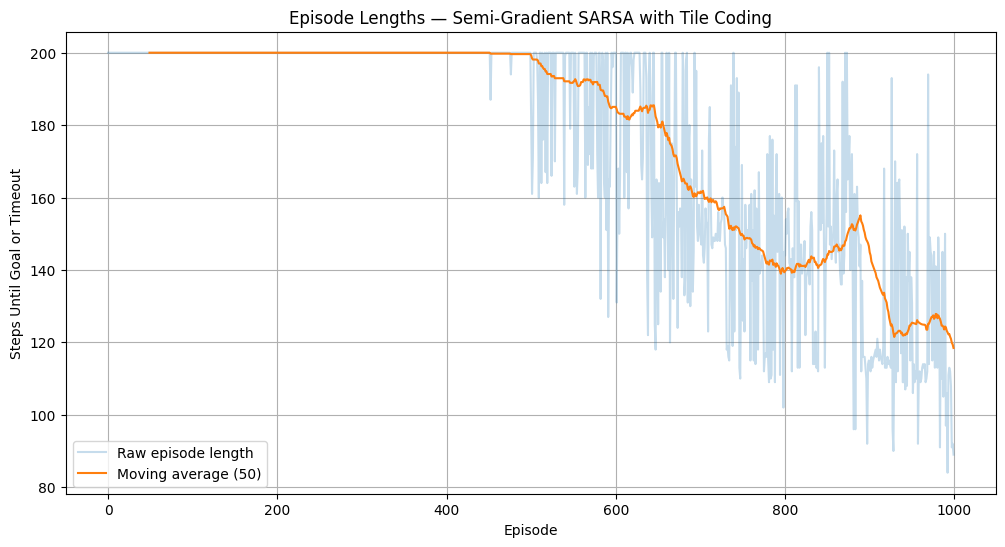

In [12]:
def plot_episode_lengths(result, window_size=50, title="Episodes-to-Goal"):
    episode_lengths = result["episode_lengths"]
    smoothed = moving_average(episode_lengths, window_size)

    plt.figure(figsize=(12, 6))
    plt.plot(episode_lengths, alpha=0.25, label="Raw episode length")
    plt.plot(
        np.arange(len(smoothed)) + window_size - 1,
        smoothed,
        label=f"Moving average ({window_size})"
    )

    plt.title(title)
    plt.xlabel("Episode")
    plt.ylabel("Steps Until Goal or Timeout")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_episode_lengths(
    main_result,
    window_size=50,
    title="Episode Lengths — Semi-Gradient SARSA with Tile Coding"
)

### Plotting Episode Returns

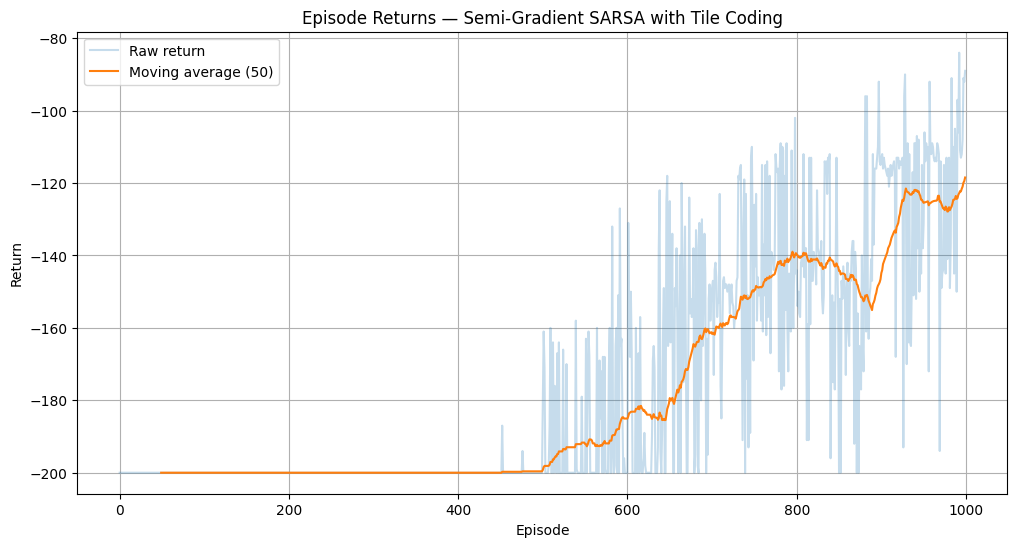

In [13]:
def plot_episode_returns(result, window_size=50, title="Episode Returns"):
    returns = result["episode_returns"]
    smoothed = moving_average(returns, window_size)

    plt.figure(figsize=(12, 6))
    plt.plot(returns, alpha=0.25, label="Raw return")
    plt.plot(
        np.arange(len(smoothed)) + window_size - 1,
        smoothed,
        label=f"Moving average ({window_size})"
    )

    plt.title(title)
    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_episode_returns(
    main_result,
    window_size=50,
    title="Episode Returns — Semi-Gradient SARSA with Tile Coding"
)

### Plotting Mean TD Error

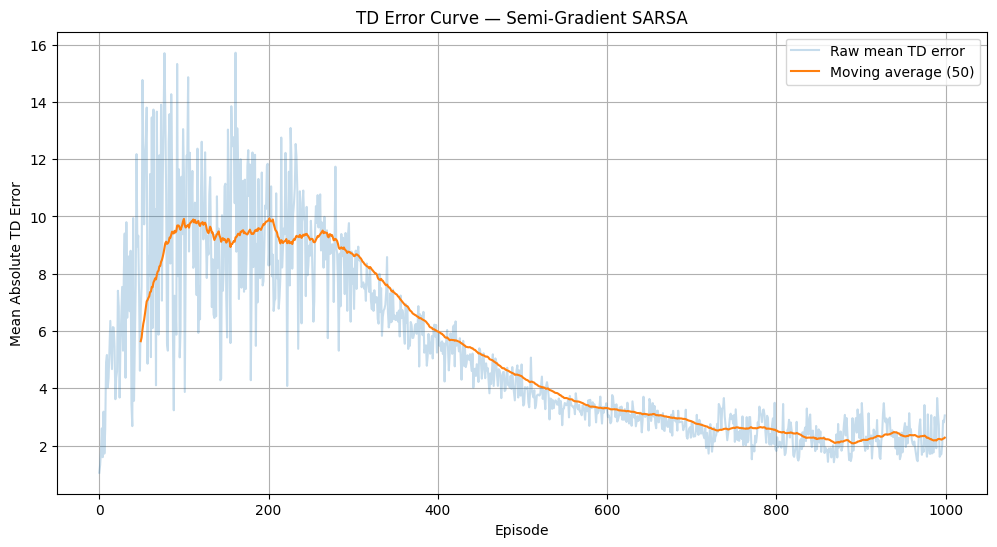

In [14]:
def plot_td_errors(result, window_size=50, title="Mean Absolute TD Error"):
    td_errors = result["td_errors"]
    smoothed = moving_average(td_errors, window_size)

    plt.figure(figsize=(12, 6))
    plt.plot(td_errors, alpha=0.25, label="Raw mean TD error")
    plt.plot(
        np.arange(len(smoothed)) + window_size - 1,
        smoothed,
        label=f"Moving average ({window_size})"
    )

    plt.title(title)
    plt.xlabel("Episode")
    plt.ylabel("Mean Absolute TD Error")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_td_errors(
    main_result,
    window_size=50,
    title="TD Error Curve — Semi-Gradient SARSA"
)

### Building Step Space Evaluation Grid

In [15]:
def build_state_grid(num_position_points=100, num_velocity_points=100):
    positions = np.linspace(POSITION_LOW, POSITION_HIGH, num_position_points)
    velocities = np.linspace(VELOCITY_LOW, VELOCITY_HIGH, num_velocity_points)

    position_grid, velocity_grid = np.meshgrid(positions, velocities)

    return positions, velocities, position_grid, velocity_grid

### Evaluating Value Function and Policy on Grid

In [16]:
def evaluate_value_and_policy_on_grid(agent, num_position_points=100, num_velocity_points=100):
    positions, velocities, position_grid, velocity_grid = build_state_grid(
        num_position_points=num_position_points,
        num_velocity_points=num_velocity_points
    )

    value_grid = np.zeros_like(position_grid, dtype=np.float64)
    policy_grid = np.zeros_like(position_grid, dtype=np.int64)

    for i in range(position_grid.shape[0]):
        for j in range(position_grid.shape[1]):
            state = np.array([position_grid[i, j], velocity_grid[i, j]])

            q_vals = agent.q_values(state)

            value_grid[i, j] = np.max(q_vals)
            policy_grid[i, j] = np.argmax(q_vals)

    return {
        "positions": positions,
        "velocities": velocities,
        "position_grid": position_grid,
        "velocity_grid": velocity_grid,
        "value_grid": value_grid,
        "policy_grid": policy_grid
    }

### Plotting Value Function Heatmap

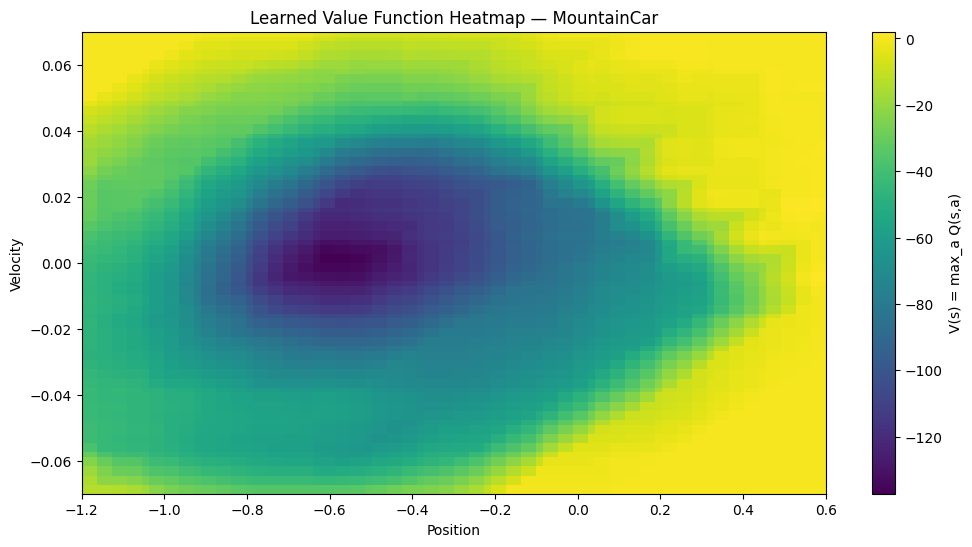

In [17]:
def plot_value_heatmap(result, title="Learned Value Function Heatmap"):
    agent = result["agent"]

    grid_eval = evaluate_value_and_policy_on_grid(agent)

    plt.figure(figsize=(12, 6))

    im = plt.imshow(
        grid_eval["value_grid"],
        origin="lower",
        aspect="auto",
        extent=[
            POSITION_LOW,
            POSITION_HIGH,
            VELOCITY_LOW,
            VELOCITY_HIGH
        ]
    )

    plt.title(title)
    plt.xlabel("Position")
    plt.ylabel("Velocity")
    plt.colorbar(im, label="V(s) = max_a Q(s,a)")
    plt.grid(False)
    plt.show()


plot_value_heatmap(
    main_result,
    title="Learned Value Function Heatmap — MountainCar"
)

### Plotting Learned Policy Heatmap

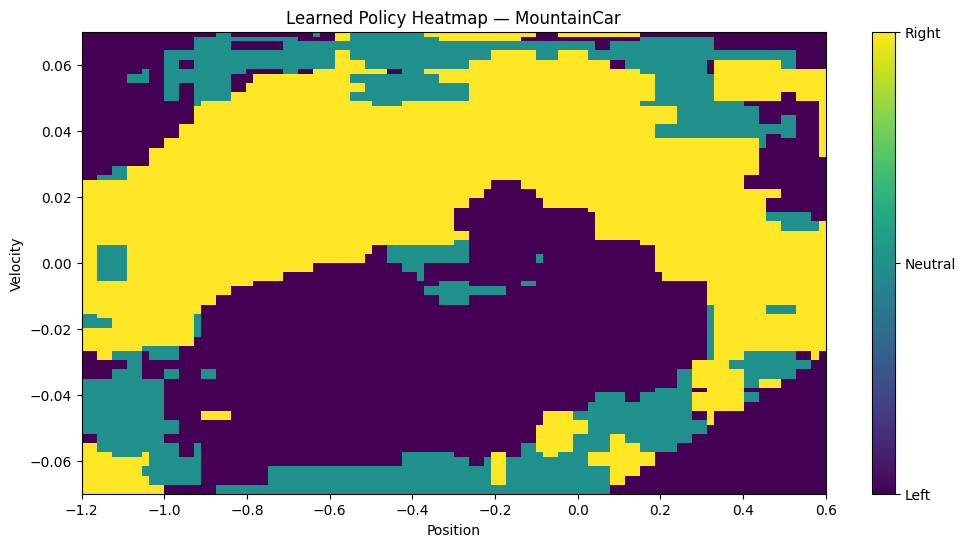

In [18]:
def plot_policy_heatmap(result, title="Learned Policy Across State Space"):
    agent = result["agent"]

    grid_eval = evaluate_value_and_policy_on_grid(agent)

    plt.figure(figsize=(12, 6))

    im = plt.imshow(
        grid_eval["policy_grid"],
        origin="lower",
        aspect="auto",
        extent=[
            POSITION_LOW,
            POSITION_HIGH,
            VELOCITY_LOW,
            VELOCITY_HIGH
        ],
        vmin=0,
        vmax=2
    )

    plt.title(title)
    plt.xlabel("Position")
    plt.ylabel("Velocity")

    cbar = plt.colorbar(im, ticks=[0, 1, 2])
    cbar.ax.set_yticklabels(["Left", "Neutral", "Right"])

    plt.grid(False)
    plt.show()


plot_policy_heatmap(
    main_result,
    title="Learned Policy Heatmap — MountainCar"
)

### Plotting Policy Arrows Direction Plot

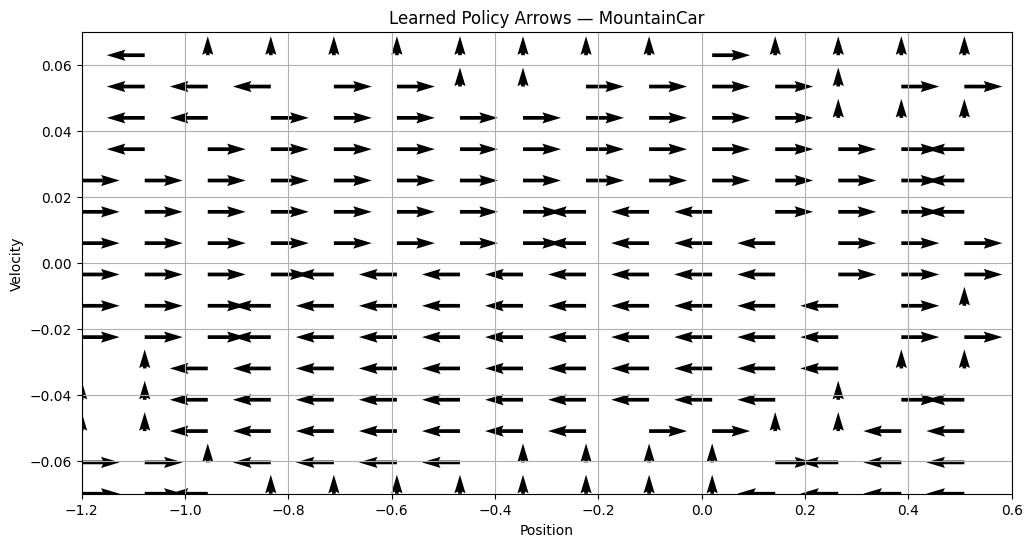

In [19]:
def plot_policy_arrows(result, skip=6, title="Learned Policy Arrows"):
    agent = result["agent"]

    grid_eval = evaluate_value_and_policy_on_grid(
        agent,
        num_position_points=60,
        num_velocity_points=60
    )

    position_grid = grid_eval["position_grid"]
    velocity_grid = grid_eval["velocity_grid"]
    policy_grid = grid_eval["policy_grid"]

    U = np.zeros_like(position_grid)
    V = np.zeros_like(velocity_grid)

    # Visual direction:
    # left action = negative horizontal arrow
    # neutral = small vertical marker
    # right action = positive horizontal arrow

    U[policy_grid == 0] = -1
    U[policy_grid == 1] = 0
    U[policy_grid == 2] = 1

    V[policy_grid == 0] = 0
    V[policy_grid == 1] = 0.5
    V[policy_grid == 2] = 0

    plt.figure(figsize=(12, 6))

    plt.quiver(
        position_grid[::skip, ::skip],
        velocity_grid[::skip, ::skip],
        U[::skip, ::skip],
        V[::skip, ::skip],
        angles="xy"
    )

    plt.title(title)
    plt.xlabel("Position")
    plt.ylabel("Velocity")
    plt.xlim(POSITION_LOW, POSITION_HIGH)
    plt.ylim(VELOCITY_LOW, VELOCITY_HIGH)
    plt.grid(True)
    plt.show()


plot_policy_arrows(
    main_result,
    skip=4,
    title="Learned Policy Arrows — MountainCar"
)

### Generating Greedy Trajectory

In [20]:
def generate_greedy_trajectory(result, start_state=None, max_steps=200, seed=123):
    env = gym.make(ENV_NAME)

    if start_state is None:
        state, info = env.reset(seed=seed)
    else:
        state, info = env.reset(seed=seed)

        # Set internal state manually for custom start.
        # MountainCar env stores the state in env.unwrapped.state.
        env.unwrapped.state = np.array(start_state, dtype=np.float64)
        state = np.array(start_state, dtype=np.float64)

    agent = result["agent"]

    states = [np.array(state, dtype=np.float64)]
    actions = []
    rewards = []

    total_reward = 0.0

    for step in range(max_steps):
        action = int(np.argmax(agent.q_values(state)))

        next_state, reward, terminated, truncated, info = env.step(action)

        states.append(np.array(next_state, dtype=np.float64))
        actions.append(action)
        rewards.append(reward)

        total_reward += reward
        state = next_state

        if terminated or truncated:
            break

    env.close()

    return {
        "states": np.array(states),
        "actions": np.array(actions),
        "rewards": np.array(rewards),
        "total_reward": total_reward,
        "steps": len(actions),
        "terminated": bool(terminated)
    }

### Plotting Sample Trajectories Over Value Function

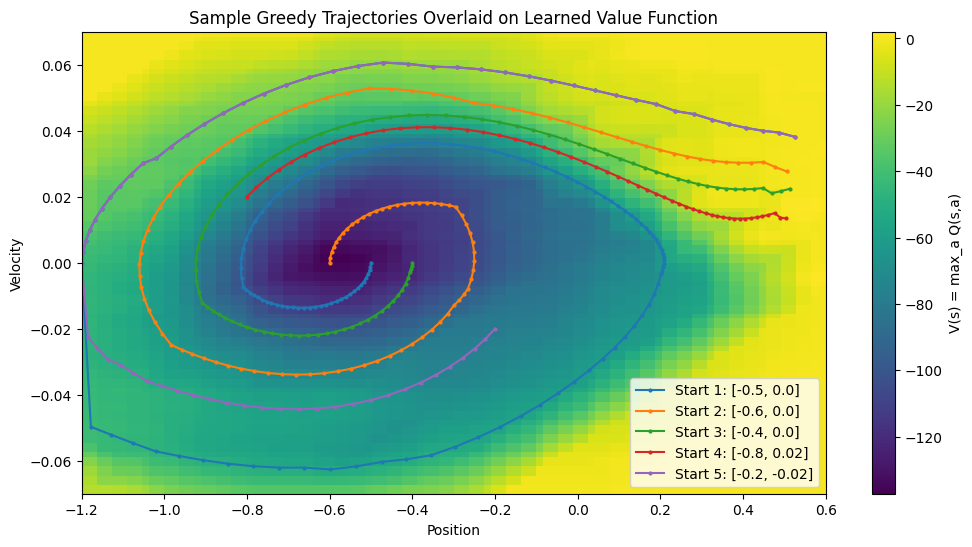

In [21]:
def plot_trajectories_on_value_function(
    result,
    start_states=None,
    title="Sample Trajectories Overlaid on Value Function"
):
    if start_states is None:
        start_states = [
            [-0.5, 0.0],
            [-0.6, 0.0],
            [-0.4, 0.0],
            [-0.8, 0.02],
            [-0.2, -0.02],
        ]

    agent = result["agent"]
    grid_eval = evaluate_value_and_policy_on_grid(agent)

    plt.figure(figsize=(12, 6))

    im = plt.imshow(
        grid_eval["value_grid"],
        origin="lower",
        aspect="auto",
        extent=[
            POSITION_LOW,
            POSITION_HIGH,
            VELOCITY_LOW,
            VELOCITY_HIGH
        ]
    )

    for idx, start_state in enumerate(start_states):
        traj = generate_greedy_trajectory(
            result,
            start_state=start_state,
            max_steps=200,
            seed=100 + idx
        )

        states = traj["states"]

        plt.plot(
            states[:, 0],
            states[:, 1],
            marker="o",
            markersize=2,
            linewidth=1.5,
            label=f"Start {idx + 1}: {start_state}"
        )

    plt.title(title)
    plt.xlabel("Position")
    plt.ylabel("Velocity")
    plt.colorbar(im, label="V(s) = max_a Q(s,a)")
    plt.legend()
    plt.grid(False)
    plt.show()


plot_trajectories_on_value_function(
    main_result,
    title="Sample Greedy Trajectories Overlaid on Learned Value Function"
)

### Feature Configuration Experiments

In [22]:
feature_configs = [
    {
        "name": "4 tilings, 8x8 tiles",
        "num_tilings": 4,
        "tiles_per_dim": (8, 8),
        "alpha": 0.4,
    },
    {
        "name": "8 tilings, 8x8 tiles",
        "num_tilings": 8,
        "tiles_per_dim": (8, 8),
        "alpha": 0.4,
    },
    {
        "name": "16 tilings, 8x8 tiles",
        "num_tilings": 16,
        "tiles_per_dim": (8, 8),
        "alpha": 0.4,
    },
    {
        "name": "8 tilings, 4x4 tiles",
        "num_tilings": 8,
        "tiles_per_dim": (4, 4),
        "alpha": 0.4,
    },
    {
        "name": "8 tilings, 12x12 tiles",
        "num_tilings": 8,
        "tiles_per_dim": (12, 12),
        "alpha": 0.4,
    },
]

### Running the Feature Experiments

In [23]:
feature_experiment_results = {}

for cfg in feature_configs:
    print("=" * 70)
    print("Training:", cfg["name"])
    print("=" * 70)

    config = MountainCarConfig(
        num_episodes=1000,
        max_steps_per_episode=200,
        alpha=cfg["alpha"],
        gamma=1.0,
        num_tilings=cfg["num_tilings"],
        tiles_per_dim=cfg["tiles_per_dim"],
        epsilon_schedule=linear_decay_epsilon(
            start=1.0,
            end=0.05,
            decay_episodes=800
        ),
        seed=42
    )

    result = train_semi_gradient_sarsa(config)
    feature_experiment_results[cfg["name"]] = result

    print("Final avg length last 100:",
          np.mean(result["episode_lengths"][-100:]))
    print("Final goal rate last 100:",
          np.mean(result["reached_goal"][-100:]))

Training: 4 tilings, 8x8 tiles
Final avg length last 100: 144.75
Final goal rate last 100: 0.94
Training: 8 tilings, 8x8 tiles
Final avg length last 100: 121.78
Final goal rate last 100: 1.0
Training: 16 tilings, 8x8 tiles
Final avg length last 100: 129.87
Final goal rate last 100: 0.99
Training: 8 tilings, 4x4 tiles
Final avg length last 100: 152.4
Final goal rate last 100: 0.81
Training: 8 tilings, 12x12 tiles
Final avg length last 100: 128.94
Final goal rate last 100: 1.0


### Plotting Convergence Curves for Feature Configurations

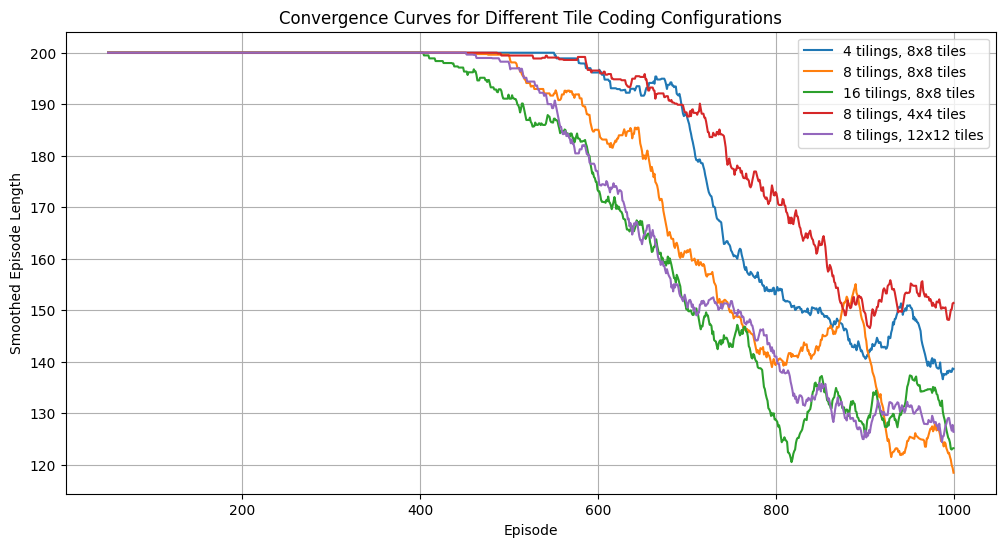

In [24]:
def plot_feature_config_convergence(feature_experiment_results, window_size=50):
    plt.figure(figsize=(12, 6))

    for name, result in feature_experiment_results.items():
        lengths = result["episode_lengths"]
        smoothed = moving_average(lengths, window_size)

        plt.plot(
            np.arange(len(smoothed)) + window_size - 1,
            smoothed,
            label=name
        )

    plt.title("Convergence Curves for Different Tile Coding Configurations")
    plt.xlabel("Episode")
    plt.ylabel("Smoothed Episode Length")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_feature_config_convergence(
    feature_experiment_results,
    window_size=50
)

### Plotting Return Curves For Feature Configurations

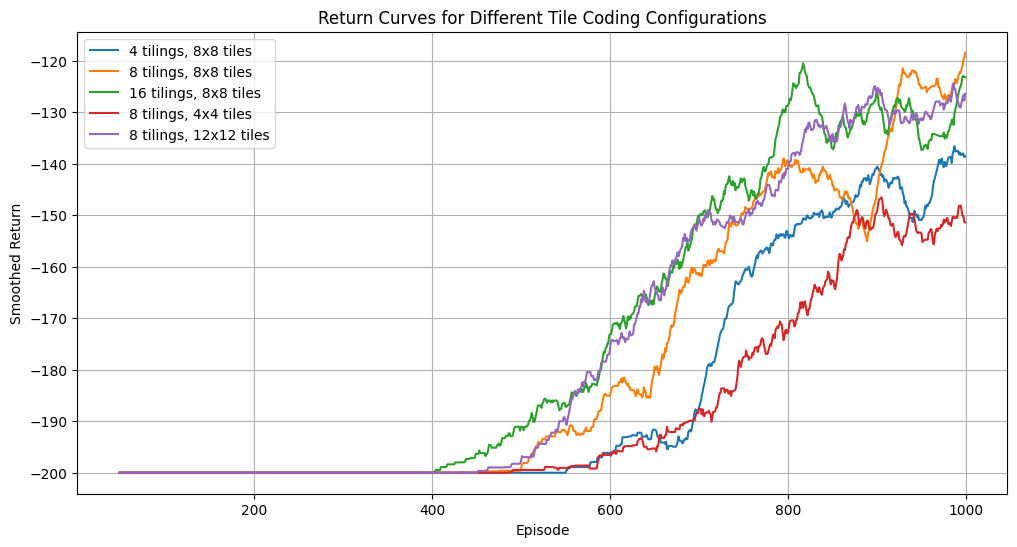

In [25]:
def plot_feature_config_returns(feature_experiment_results, window_size=50):
    plt.figure(figsize=(12, 6))

    for name, result in feature_experiment_results.items():
        returns = result["episode_returns"]
        smoothed = moving_average(returns, window_size)

        plt.plot(
            np.arange(len(smoothed)) + window_size - 1,
            smoothed,
            label=name
        )

    plt.title("Return Curves for Different Tile Coding Configurations")
    plt.xlabel("Episode")
    plt.ylabel("Smoothed Return")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_feature_config_returns(
    feature_experiment_results,
    window_size=50
)

### Epsilon Schedule Experiments

In [26]:
epsilon_configs = {
    "constant epsilon = 0.1": constant_epsilon(0.1),
    "linear decay 1.0 to 0.05": linear_decay_epsilon(
        start=1.0,
        end=0.05,
        decay_episodes=800
    ),
    "exponential decay 1.0 to 0.05": exponential_decay_epsilon(
        start=1.0,
        end=0.05,
        decay_rate=0.995
    ),
}

### Running Epsilon Schedule Experiments

In [27]:
epsilon_experiment_results = {}

for name, eps_schedule in epsilon_configs.items():
    print("=" * 70)
    print("Training:", name)
    print("=" * 70)

    config = MountainCarConfig(
        num_episodes=1000,
        max_steps_per_episode=200,
        alpha=0.4,
        gamma=1.0,
        num_tilings=8,
        tiles_per_dim=(8, 8),
        epsilon_schedule=eps_schedule,
        seed=42
    )

    result = train_semi_gradient_sarsa(config)
    epsilon_experiment_results[name] = result

    print("Final avg length last 100:",
          np.mean(result["episode_lengths"][-100:]))
    print("Final goal rate last 100:",
          np.mean(result["reached_goal"][-100:]))

Training: constant epsilon = 0.1
Final avg length last 100: 140.69
Final goal rate last 100: 0.98
Training: linear decay 1.0 to 0.05
Final avg length last 100: 121.78
Final goal rate last 100: 1.0
Training: exponential decay 1.0 to 0.05
Final avg length last 100: 135.65
Final goal rate last 100: 0.98


### Plotting Epsilon Schedule Values

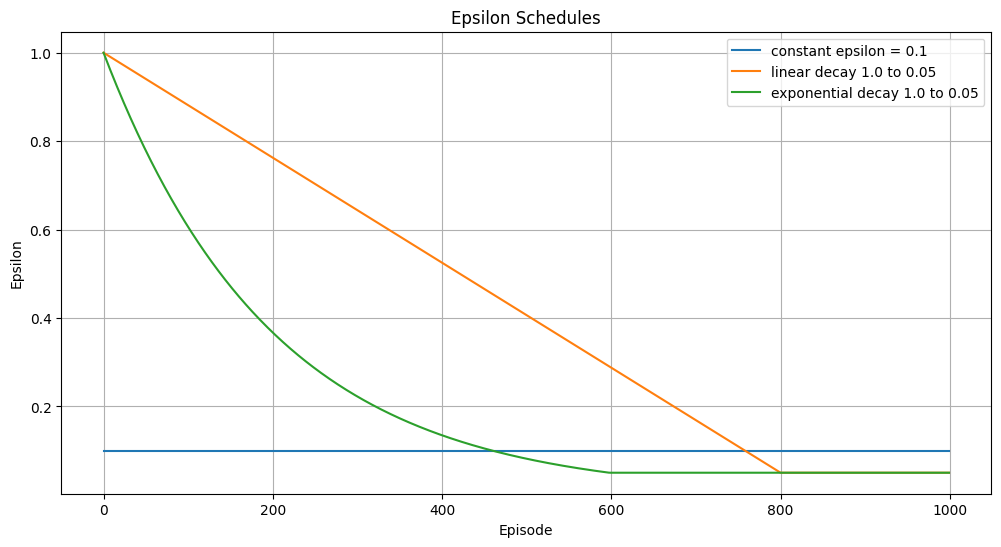

In [28]:
def plot_epsilon_schedules(schedule_dict, num_episodes=1000):
    episodes = np.arange(num_episodes)

    plt.figure(figsize=(12, 6))

    for name, schedule_fn in schedule_dict.items():
        eps_values = np.array([schedule_fn(ep) for ep in episodes])
        plt.plot(episodes, eps_values, label=name)

    plt.title("Epsilon Schedules")
    plt.xlabel("Episode")
    plt.ylabel("Epsilon")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_epsilon_schedules(
    epsilon_configs,
    num_episodes=1000
)

### Plotting Epsilon Schedule Experiment Convergence Curves

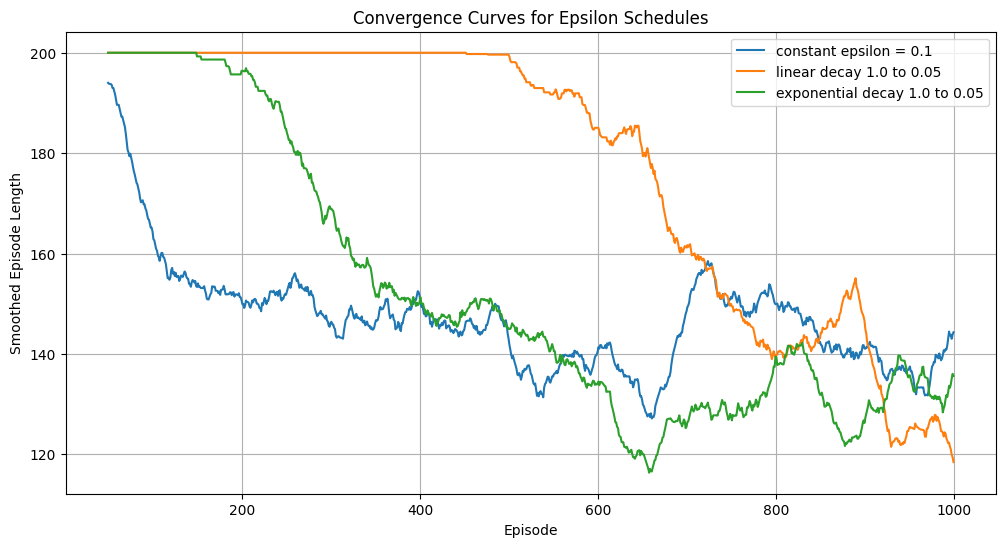

In [29]:
def plot_epsilon_experiment_convergence(epsilon_experiment_results, window_size=50):
    plt.figure(figsize=(12, 6))

    for name, result in epsilon_experiment_results.items():
        lengths = result["episode_lengths"]
        smoothed = moving_average(lengths, window_size)

        plt.plot(
            np.arange(len(smoothed)) + window_size - 1,
            smoothed,
            label=name
        )

    plt.title("Convergence Curves for Epsilon Schedules")
    plt.xlabel("Episode")
    plt.ylabel("Smoothed Episode Length")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_epsilon_experiment_convergence(
    epsilon_experiment_results,
    window_size=50
)

### Alpha Experiments

In [30]:
alpha_values = [0.1, 0.2, 0.4, 0.8]
alpha_experiment_results = {}

for alpha in alpha_values:
    name = f"alpha = {alpha}"

    print("=" * 70)
    print("Training:", name)
    print("=" * 70)

    config = MountainCarConfig(
        num_episodes=1000,
        max_steps_per_episode=200,
        alpha=alpha,
        gamma=1.0,
        num_tilings=8,
        tiles_per_dim=(8, 8),
        epsilon_schedule=linear_decay_epsilon(
            start=1.0,
            end=0.05,
            decay_episodes=800
        ),
        seed=42
    )

    result = train_semi_gradient_sarsa(config)
    alpha_experiment_results[name] = result

    print("Final avg length last 100:",
          np.mean(result["episode_lengths"][-100:]))
    print("Final goal rate last 100:",
          np.mean(result["reached_goal"][-100:]))

Training: alpha = 0.1
Final avg length last 100: 139.95
Final goal rate last 100: 1.0
Training: alpha = 0.2
Final avg length last 100: 132.93
Final goal rate last 100: 1.0
Training: alpha = 0.4
Final avg length last 100: 121.78
Final goal rate last 100: 1.0
Training: alpha = 0.8
Final avg length last 100: 160.15
Final goal rate last 100: 0.92


### Plotting Alpha Experiment Convergence Curves

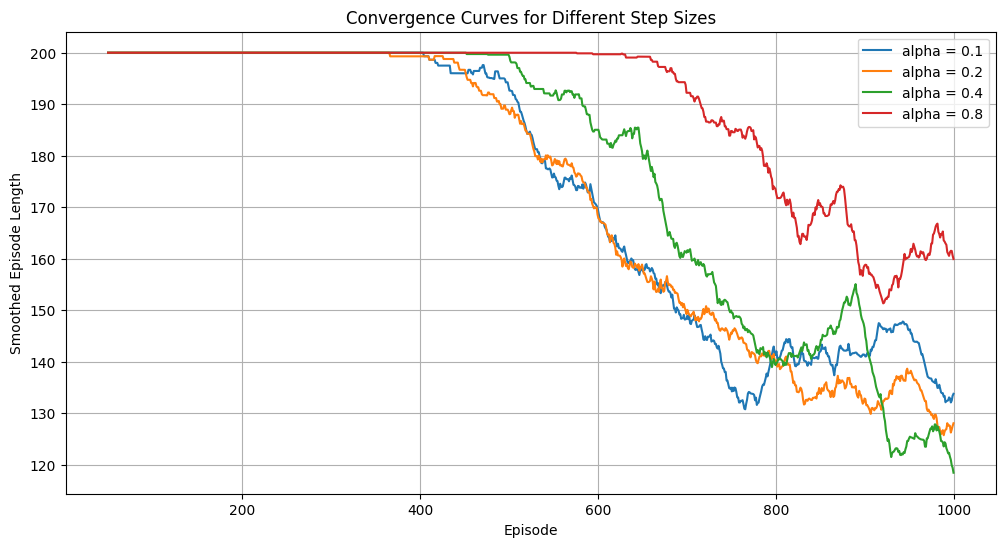

In [31]:
def plot_alpha_experiment_convergence(alpha_experiment_results, window_size=50):
    plt.figure(figsize=(12, 6))

    for name, result in alpha_experiment_results.items():
        lengths = result["episode_lengths"]
        smoothed = moving_average(lengths, window_size)

        plt.plot(
            np.arange(len(smoothed)) + window_size - 1,
            smoothed,
            label=name
        )

    plt.title("Convergence Curves for Different Step Sizes")
    plt.xlabel("Episode")
    plt.ylabel("Smoothed Episode Length")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_alpha_experiment_convergence(
    alpha_experiment_results,
    window_size=50
)

### Evaluating Function

In [32]:
def evaluate_greedy_policy(result, num_eval_episodes=100, seed=999):
    env = gym.make(ENV_NAME)
    agent = result["agent"]

    returns = np.zeros(num_eval_episodes, dtype=np.float64)
    lengths = np.zeros(num_eval_episodes, dtype=np.int64)
    successes = np.zeros(num_eval_episodes, dtype=bool)

    for ep in range(num_eval_episodes):
        state, info = env.reset(seed=seed + ep)

        total_reward = 0.0

        for step in range(200):
            action = int(np.argmax(agent.q_values(state)))

            next_state, reward, terminated, truncated, info = env.step(action)

            total_reward += reward
            state = next_state

            if terminated:
                successes[ep] = True
                break

            if truncated:
                break

        returns[ep] = total_reward
        lengths[ep] = step + 1

    env.close()

    return {
        "mean_return": np.mean(returns),
        "std_return": np.std(returns, ddof=1),
        "mean_length": np.mean(lengths),
        "std_length": np.std(lengths, ddof=1),
        "success_rate": np.mean(successes),
        "returns": returns,
        "lengths": lengths,
        "successes": successes
    }

### Summary Metrics

In [33]:
def summarize_result(name, result, final_window=100):
    eval_stats = evaluate_greedy_policy(result)

    cfg = result["config"]
    tile_coder = result["tile_coder"]

    final_avg_length = np.mean(result["episode_lengths"][-final_window:])
    final_avg_return = np.mean(result["episode_returns"][-final_window:])
    final_success_rate = np.mean(result["reached_goal"][-final_window:])

    first_success_episode = np.argmax(result["reached_goal"])

    if not np.any(result["reached_goal"]):
        first_success_episode = np.nan

    return {
        "Name": name,
        "Num Tilings": cfg.num_tilings,
        "Tiles Per Dim": str(cfg.tiles_per_dim),
        "Total Features": tile_coder.total_features,
        "Alpha": cfg.alpha,
        "Final Avg Length": final_avg_length,
        "Final Avg Return": final_avg_return,
        "Final Success Rate": final_success_rate,
        "First Success Episode": first_success_episode,
        "Eval Mean Length": eval_stats["mean_length"],
        "Eval Mean Return": eval_stats["mean_return"],
        "Eval Success Rate": eval_stats["success_rate"]
    }

### Comparison Table: Feature Configurations

In [34]:
feature_summary_rows = []

for name, result in feature_experiment_results.items():
    feature_summary_rows.append(summarize_result(name, result))

feature_summary_df = pd.DataFrame(feature_summary_rows)

feature_summary_df

,Name,Num Tilings,Tiles Per Dim,Total Features,Alpha,Final Avg Length,Final Avg Return,Final Success Rate,First Success Episode,Eval Mean Length,Eval Mean Return,Eval Success Rate
0,"4 tilings, 8x8 tiles",4,"(8, 8)",256,0.4,144.75,-144.75,0.94,551,152.72,-152.72,1.00
1,"8 tilings, 8x8 tiles",8,"(8, 8)",512,0.4,121.78,-121.78,1.00,452,112.98,-112.98,1.00
2,"16 tilings, 8x8 tiles",16,"(8, 8)",1024,0.4,129.87,-129.87,0.99,404,108.96,-108.96,1.00
3,"8 tilings, 4x4 tiles",8,"(4, 4)",128,0.4,152.40,-152.40,0.81,487,143.95,-143.95,0.93
4,"8 tilings, 12x12 tiles",8,"(12, 12)",1152,0.4,128.94,-128.94,1.00,452,107.47,-107.47,1.00


### Comparison Table: Epsilon Schedules

In [35]:
epsilon_summary_rows = []

for name, result in epsilon_experiment_results.items():
    epsilon_summary_rows.append(summarize_result(name, result))

epsilon_summary_df = pd.DataFrame(epsilon_summary_rows)

epsilon_summary_df

,Name,Num Tilings,Tiles Per Dim,Total Features,Alpha,Final Avg Length,Final Avg Return,Final Success Rate,First Success Episode,Eval Mean Length,Eval Mean Return,Eval Success Rate
0,constant epsilon = 0.1,8,"(8, 8)",512,0.4,140.69,-140.69,0.98,24,167.00,-167.00,0.81
1,linear decay 1.0 to 0.05,8,"(8, 8)",512,0.4,121.78,-121.78,1.00,452,112.98,-112.98,1.00
2,exponential decay 1.0 to 0.05,8,"(8, 8)",512,0.4,135.65,-135.65,0.98,149,145.34,-145.34,1.00


### Comparison Table: Alpha Values

In [36]:
alpha_summary_rows = []

for name, result in alpha_experiment_results.items():
    alpha_summary_rows.append(summarize_result(name, result))

alpha_summary_df = pd.DataFrame(alpha_summary_rows)

alpha_summary_df

,Name,Num Tilings,Tiles Per Dim,Total Features,Alpha,Final Avg Length,Final Avg Return,Final Success Rate,First Success Episode,Eval Mean Length,Eval Mean Return,Eval Success Rate
0,alpha = 0.1,8,"(8, 8)",512,0.1,139.95,-139.95,1.00,404,124.88,-124.88,1.00
1,alpha = 0.2,8,"(8, 8)",512,0.2,132.93,-132.93,1.00,366,117.41,-117.41,1.00
2,alpha = 0.4,8,"(8, 8)",512,0.4,121.78,-121.78,1.00,452,112.98,-112.98,1.00
3,alpha = 0.8,8,"(8, 8)",512,0.8,160.15,-160.15,0.92,576,175.10,-175.10,0.98


### Select Best Feature Configuration

In [37]:
best_feature_name = feature_summary_df.sort_values(
    by=["Eval Success Rate", "Eval Mean Length"],
    ascending=[False, True]
).iloc[0]["Name"]

best_result = feature_experiment_results[best_feature_name]

print("Best feature configuration:", best_feature_name)
print(feature_summary_df[feature_summary_df["Name"] == best_feature_name])

Best feature configuration: 8 tilings, 12x12 tiles
                     Name  Num Tilings Tiles Per Dim  Total Features  Alpha  \
4  8 tilings, 12x12 tiles            8      (12, 12)            1152    0.4   

   Final Avg Length  Final Avg Return  Final Success Rate  \
4            128.94           -128.94                 1.0   

   First Success Episode  Eval Mean Length  Eval Mean Return  \
4                    452            107.47           -107.47   

   Eval Success Rate  
4                1.0  


### Plotting the Final Plots for Best Results

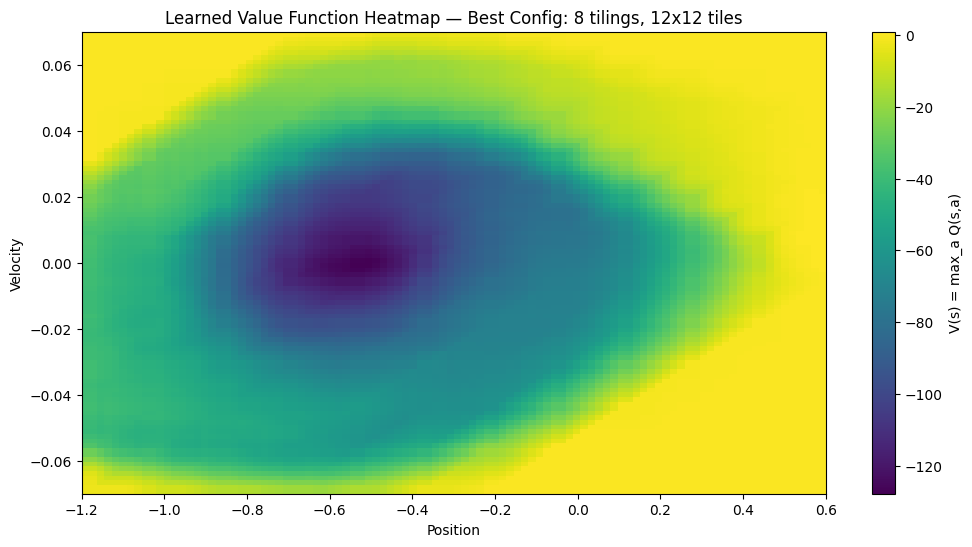

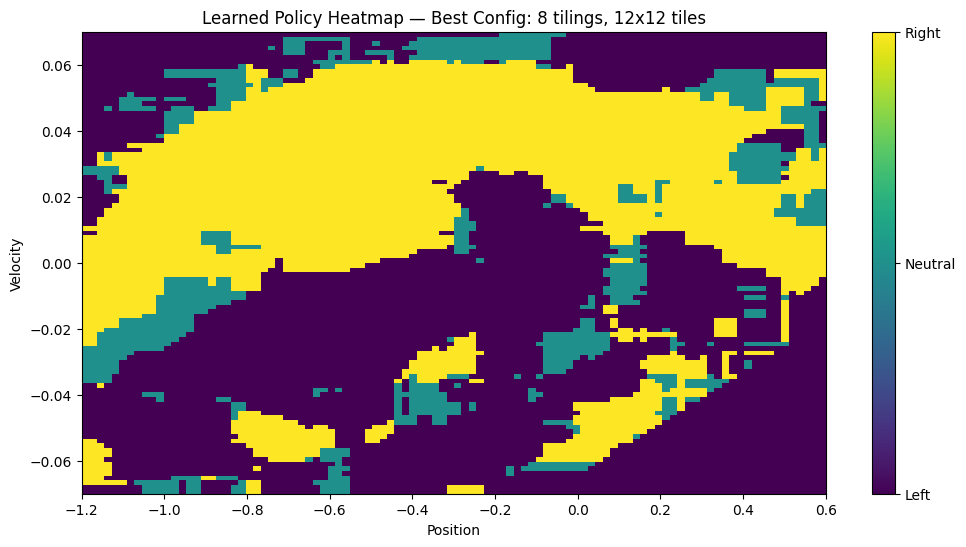

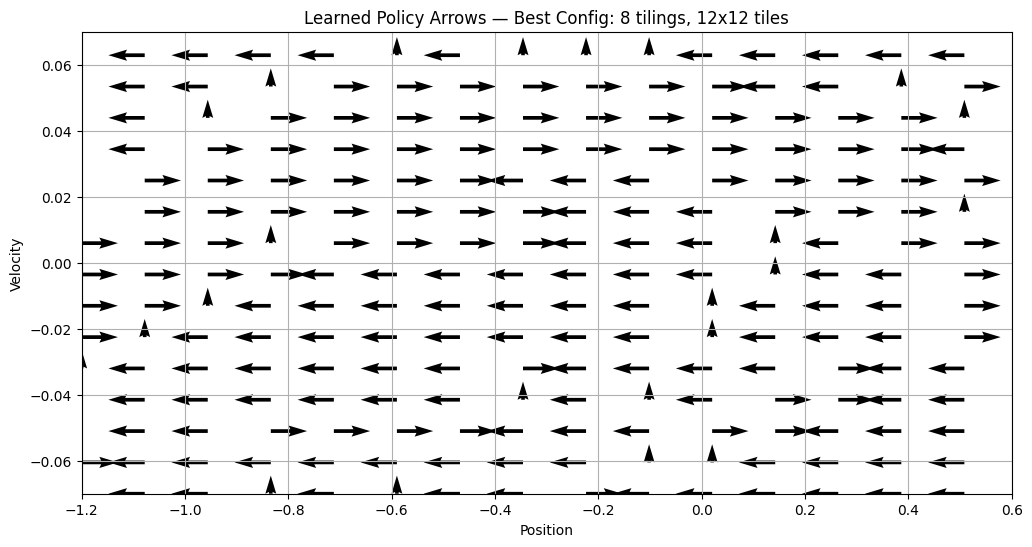

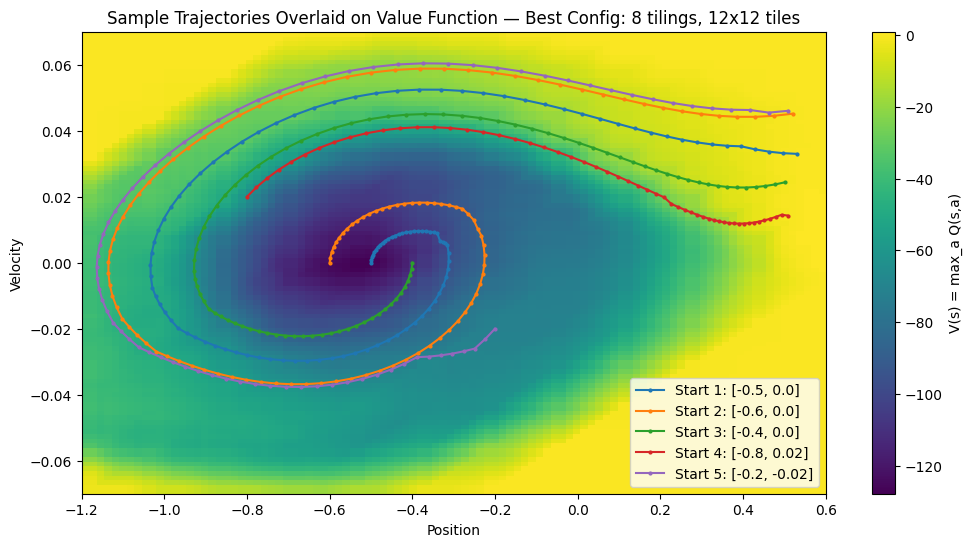

In [38]:
plot_value_heatmap(
    best_result,
    title=f"Learned Value Function Heatmap — Best Config: {best_feature_name}"
)

plot_policy_heatmap(
    best_result,
    title=f"Learned Policy Heatmap — Best Config: {best_feature_name}"
)

plot_policy_arrows(
    best_result,
    skip=4,
    title=f"Learned Policy Arrows — Best Config: {best_feature_name}"
)

plot_trajectories_on_value_function(
    best_result,
    title=f"Sample Trajectories Overlaid on Value Function — Best Config: {best_feature_name}"
)

### Saving The Tables

In [39]:
feature_summary_df.to_csv("feature_configuration_comparison.csv", index=False)
epsilon_summary_df.to_csv("epsilon_schedule_comparison.csv", index=False)
alpha_summary_df.to_csv("alpha_comparison.csv", index=False)